In [661]:
import numpy as np
import pandas as pd 
import missingno as msno
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [662]:
data=pd.read_csv("fifa21 raw data v2.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_11848\2840900921.py:1: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("fifa21 raw data v2.csv")


In [663]:
data.shape
data.drop_duplicates(inplace=True)


In [664]:
data.rename(columns= {"↓ova": "ova"}, inplace= True)

In [665]:
data['Hits']=data['Hits'].str.replace('K','').astype(float)
data['Hits']=data['Hits'].fillna(data['Hits'].mode()[0])

In [666]:
data['Height']=data['Height'].str.replace('cm','')
data['Weight']=data['Weight'].str.replace('lbs','')

data['Weight']=data['Weight'].str.replace('kg','').astype(int)
# data['Value']=data['Value'].str.replace('€','')
# data['Wage']=data['Wage'].str.replace('€','')
# data['Release Clause']=data['Release Clause'].str.replace('€','')
# data['Release Clause']=data['Release Clause'].str.replace('M','000000')
# data['Release Clause']=data['Release Clause'].str.replace('K','000').astype(float)
# data['Value']=data['Value'].str.replace('M','000000')
# data['Value']=data['Value'].str.replace('K','000').astype(float)
# data['Wage']=data['Wage'].str.replace('K','000').astype(float)





In [667]:
def remove1(val1):
    val1=str(val1).replace('€','')
    if val1.endswith('M'):
        return float(val1.replace('M',''))*1000000
    elif val1.endswith('K'):
        return float(val1.replace('K',''))*1000
    else:
       return float(val1)

data['Value']=data['Value'].apply(remove1)
data['Wage']=data['Wage'].apply(remove1)
data['Release Clause']=data['Release Clause'].apply(remove1)

In [668]:
ll=['Club','Nationality','A/W','D/W','W/F','SM','IR']
le=LabelEncoder()
for col in ll:
    data[col]=le.fit_transform(data[col])

In [669]:
data = data.drop('Loan Date End', axis=1, errors='ignore')


In [670]:
data[['Contract start','Contract end']]=data['Contract'].str.split(' ~ ',expand=True)
data = data.drop('Contract', axis=1, errors='ignore')



In [671]:
data['Joined']=pd.to_datetime(data['Joined'])
year=data[2026-data['Joined'].dt.year>10]
print(year['Name'])



0                 L. Messi
2                 J. Oblak
3             K. De Bruyne
5           R. Lewandowski
9            M. ter Stegen
               ...        
18390           J. Stevens
18416        B. Al Bahrani
18781            S. Callan
18915    Chen-Zeng Tailang
18917            Gao Xiang
Name: Name, Length: 1658, dtype: object


In [672]:
total=0
for i in year['Wage']:
    total+=i
avg=total/len(data['Wage'])
print(avg)
    

1626.750619105327


In [673]:
iss=data[data['Wage']>avg]
print(iss['Name'])


0                 L. Messi
1        Cristiano Ronaldo
2                 J. Oblak
3             K. De Bruyne
4                Neymar Jr
               ...        
18953        Shan Huanhuan
18957         Wang Jianwen
18961           L. Waldock
18969             Song Yue
18977         Wang Zhen'ao
Name: Name, Length: 13138, dtype: object


In [674]:
data['Join year']=data['Joined'].dt.year
data['Join month']=data['Joined'].dt.month
data['Join day']=data['Joined'].dt.day
data = data.drop('Joined', axis=1, errors='ignore')
print(data['Club'].dtype)
data['Club']=data['Club'].astype(str)



int64


In [675]:
for i in data.columns:
    if data[i].dtype=='Object':
        data[i]=data[i].str.strip("\n")


In [676]:
min_count = data['Preferred Foot'].value_counts().min()

balanced_list = []
for city, group in data.groupby('Preferred Foot'):
    balanced_list.append(group.sample(min_count))
data_balanced = pd.concat(balanced_list).reset_index(drop=True)




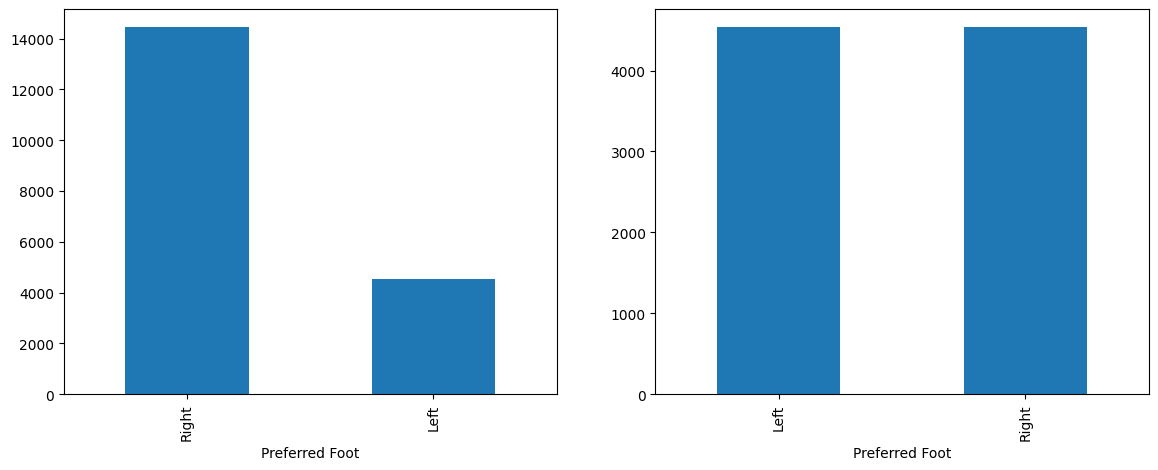

In [677]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data['Preferred Foot'].value_counts().plot(kind='bar', ax=axes[0])
data_balanced['Preferred Foot'].value_counts().plot(kind='bar', ax=axes[1])

plt.show()

In [678]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 79 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18979 non-null  int64  
 1   Name              18979 non-null  object 
 2   LongName          18979 non-null  object 
 3   photoUrl          18979 non-null  object 
 4   playerUrl         18979 non-null  object 
 5   Nationality       18979 non-null  int64  
 6   Age               18979 non-null  int64  
 7   ↓OVA              18979 non-null  int64  
 8   POT               18979 non-null  int64  
 9   Club              18979 non-null  object 
 10  Positions         18979 non-null  object 
 11  Height            18979 non-null  object 
 12  Weight            18979 non-null  int64  
 13  Preferred Foot    18979 non-null  object 
 14  BOV               18979 non-null  int64  
 15  Best Position     18979 non-null  object 
 16  Value             18979 non-null  float6